# Machine Learning Final Project
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

In [13]:
# Import data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [14]:
# Load datatypes for final_food_data
with open('final_food_data_dtypes.json', 'r') as f:
    final_food_data_dtypes = json.load(f)

# Load processed dataset
food_data = pd.read_csv('final_food_data.csv', dtype=final_food_data_dtypes)

In [15]:
# Nutrient columns: all columns containing 'amount', excluding logs and package weight
nutrient_cols = [col for col in food_data.columns if ('amount' in col and not col.endswith('_log') and col != 'package_weight_amount')]
# Filter out nutrient columns with >90% zeros
nutrient_cols = [col for col in nutrient_cols if (food_data[col] == 0).mean() <= 0.9]
print(f'Nutrient columns selected ({len(nutrient_cols)}): {nutrient_cols}')

# Ingredient one-hot columns: all columns starting with 'ingredient_oh_'
ingredient_oh_cols = [col for col in food_data.columns if col.startswith('ingredient_oh_')]
# Filter out ingredient one-hot columns with >90% zeros
ingredient_oh_cols = [col for col in ingredient_oh_cols if (food_data[col] == 0).mean() <= 0.9]
print(f'Ingredient one-hot columns selected ({len(ingredient_oh_cols)}): {ingredient_oh_cols[:10]} ...')

# Feature columns: all columns except nutrient columns and dropped ingredient columns
exclude_cols = set(nutrient_cols)
exclude_cols.update(set(ingredient_oh_cols))
feature_cols = [col for col in food_data.columns if col not in exclude_cols]
print(f'Feature columns selected ({len(feature_cols)}): {feature_cols[:10]} ...')

Nutrient columns selected (15): ['Calcium, Ca amount', 'Carbohydrate, by difference amount', 'Cholesterol amount', 'Energy amount', 'Fatty acids, total saturated amount', 'Fiber, total dietary amount', 'Iron, Fe amount', 'Potassium, K amount', 'Protein amount', 'Sodium, Na amount', 'Sugars, added amount', 'Total Sugars amount', 'Total lipid (fat) amount', 'Vitamin A, IU amount', 'Vitamin C, total ascorbic acid amount']
Ingredient one-hot columns selected (8): ['ingredient_oh_salt', 'ingredient_oh_sugar', 'ingredient_oh_water', 'ingredient_oh_citricAcid', 'ingredient_oh_cornSyrup', 'ingredient_oh_naturalFlavor', 'ingredient_oh_soyLecithin', 'ingredient_oh_seaSalt'] ...
Feature columns selected (304): ['serving_size', 'Acetic acid amount', 'Alanine amount', 'Alcohol, ethyl amount', 'Arginine amount', 'Ash amount', 'Aspartic acid amount', 'Beta-glucans amount', 'Biotin amount', 'Caffeine amount'] ...


In [16]:
# Prepare X and y for linear regression (no windowing)
X = food_data[feature_cols].values
y = food_data[nutrient_cols].values

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict on test set
y_pred_lr = linreg.predict(X_test)

In [17]:
# Evaluate linear regression benchmark
rmses_lr = [np.sqrt(mean_squared_error(y_test[:, i], y_pred_lr[:, i])) for i in range(len(nutrient_cols))]
def r2_score_lr(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0
r2s_lr = [r2_score_lr(y_test[:, i], y_pred_lr[:, i]) for i in range(len(nutrient_cols))]
residuals_lr = y_test - y_pred_lr

print('Linear Regression RMSEs:')
for col, rmse in zip(nutrient_cols, rmses_lr):
    print(f'RMSE for {col}: {rmse:.4f}')

print('\nLinear Regression R squared:')
for col, r2 in zip(nutrient_cols, r2s_lr):
    print(f'R squared for {col}: {r2:.4f}')

print('\nLinear Regression Residuals shape:', residuals_lr.shape)

Linear Regression RMSEs:
RMSE for Calcium, Ca amount: 2.5914
RMSE for Carbohydrate, by difference amount: 46.4948
RMSE for Cholesterol amount: 0.0042
RMSE for Energy amount: 0.2736
RMSE for Fatty acids, total saturated amount: 7.6055
RMSE for Fiber, total dietary amount: 6.4589
RMSE for Iron, Fe amount: 0.2380
RMSE for Potassium, K amount: 0.1313
RMSE for Protein amount: 11.8424
RMSE for Sodium, Na amount: 0.2733
RMSE for Sugars, added amount: 13.8526
RMSE for Total Sugars amount: 31.6034
RMSE for Total lipid (fat) amount: 16.5244
RMSE for Vitamin A, IU amount: 0.1042
RMSE for Vitamin C, total ascorbic acid amount: 0.1555

Linear Regression R squared:
R squared for Calcium, Ca amount: -0.0010
R squared for Carbohydrate, by difference amount: 0.0605
R squared for Cholesterol amount: 0.9998
R squared for Energy amount: 0.1711
R squared for Fatty acids, total saturated amount: 0.2195
R squared for Fiber, total dietary amount: 0.0857
R squared for Iron, Fe amount: 0.3627
R squared for Pota

In [18]:
print('Linear Regression RMSE Summary:')
print(f'Mean RMSE: {np.mean(rmses_lr):.4f}')
print(f'Median RMSE: {np.median(rmses_lr):.4f}')
print(f'Min RMSE: {np.min(rmses_lr):.4f}')
print(f'Max RMSE: {np.max(rmses_lr):.4f}\n')

Linear Regression RMSE Summary:
Mean RMSE: 9.2102
Median RMSE: 2.5914
Min RMSE: 0.0042
Max RMSE: 46.4948



In [19]:
print('Linear Regression R squared Summary:')
print(f'Mean R^2: {np.mean(r2s_lr):.4f}')
print(f'Median R^2: {np.median(r2s_lr):.4f}')
print(f'Min R^2: {np.min(r2s_lr):.4f}')
print(f'Max R^2: {np.max(r2s_lr):.4f}\n')

Linear Regression R squared Summary:
Mean R^2: 0.3036
Median R^2: 0.1711
Min R^2: -0.0010
Max R^2: 0.9998



In [20]:
print('Linear Regression Residuals Summary:')
print(f'Mean residual: {np.mean(residuals_lr):.4f}')
print(f'Median residual: {np.median(residuals_lr):.4f}')
print(f'Min residual: {np.min(residuals_lr):.4f}')
print(f'Max residual: {np.max(residuals_lr):.4f}')

Linear Regression Residuals Summary:
Mean residual: -0.0082
Median residual: -0.0075
Min residual: -1983.9135
Max residual: 7214.6358


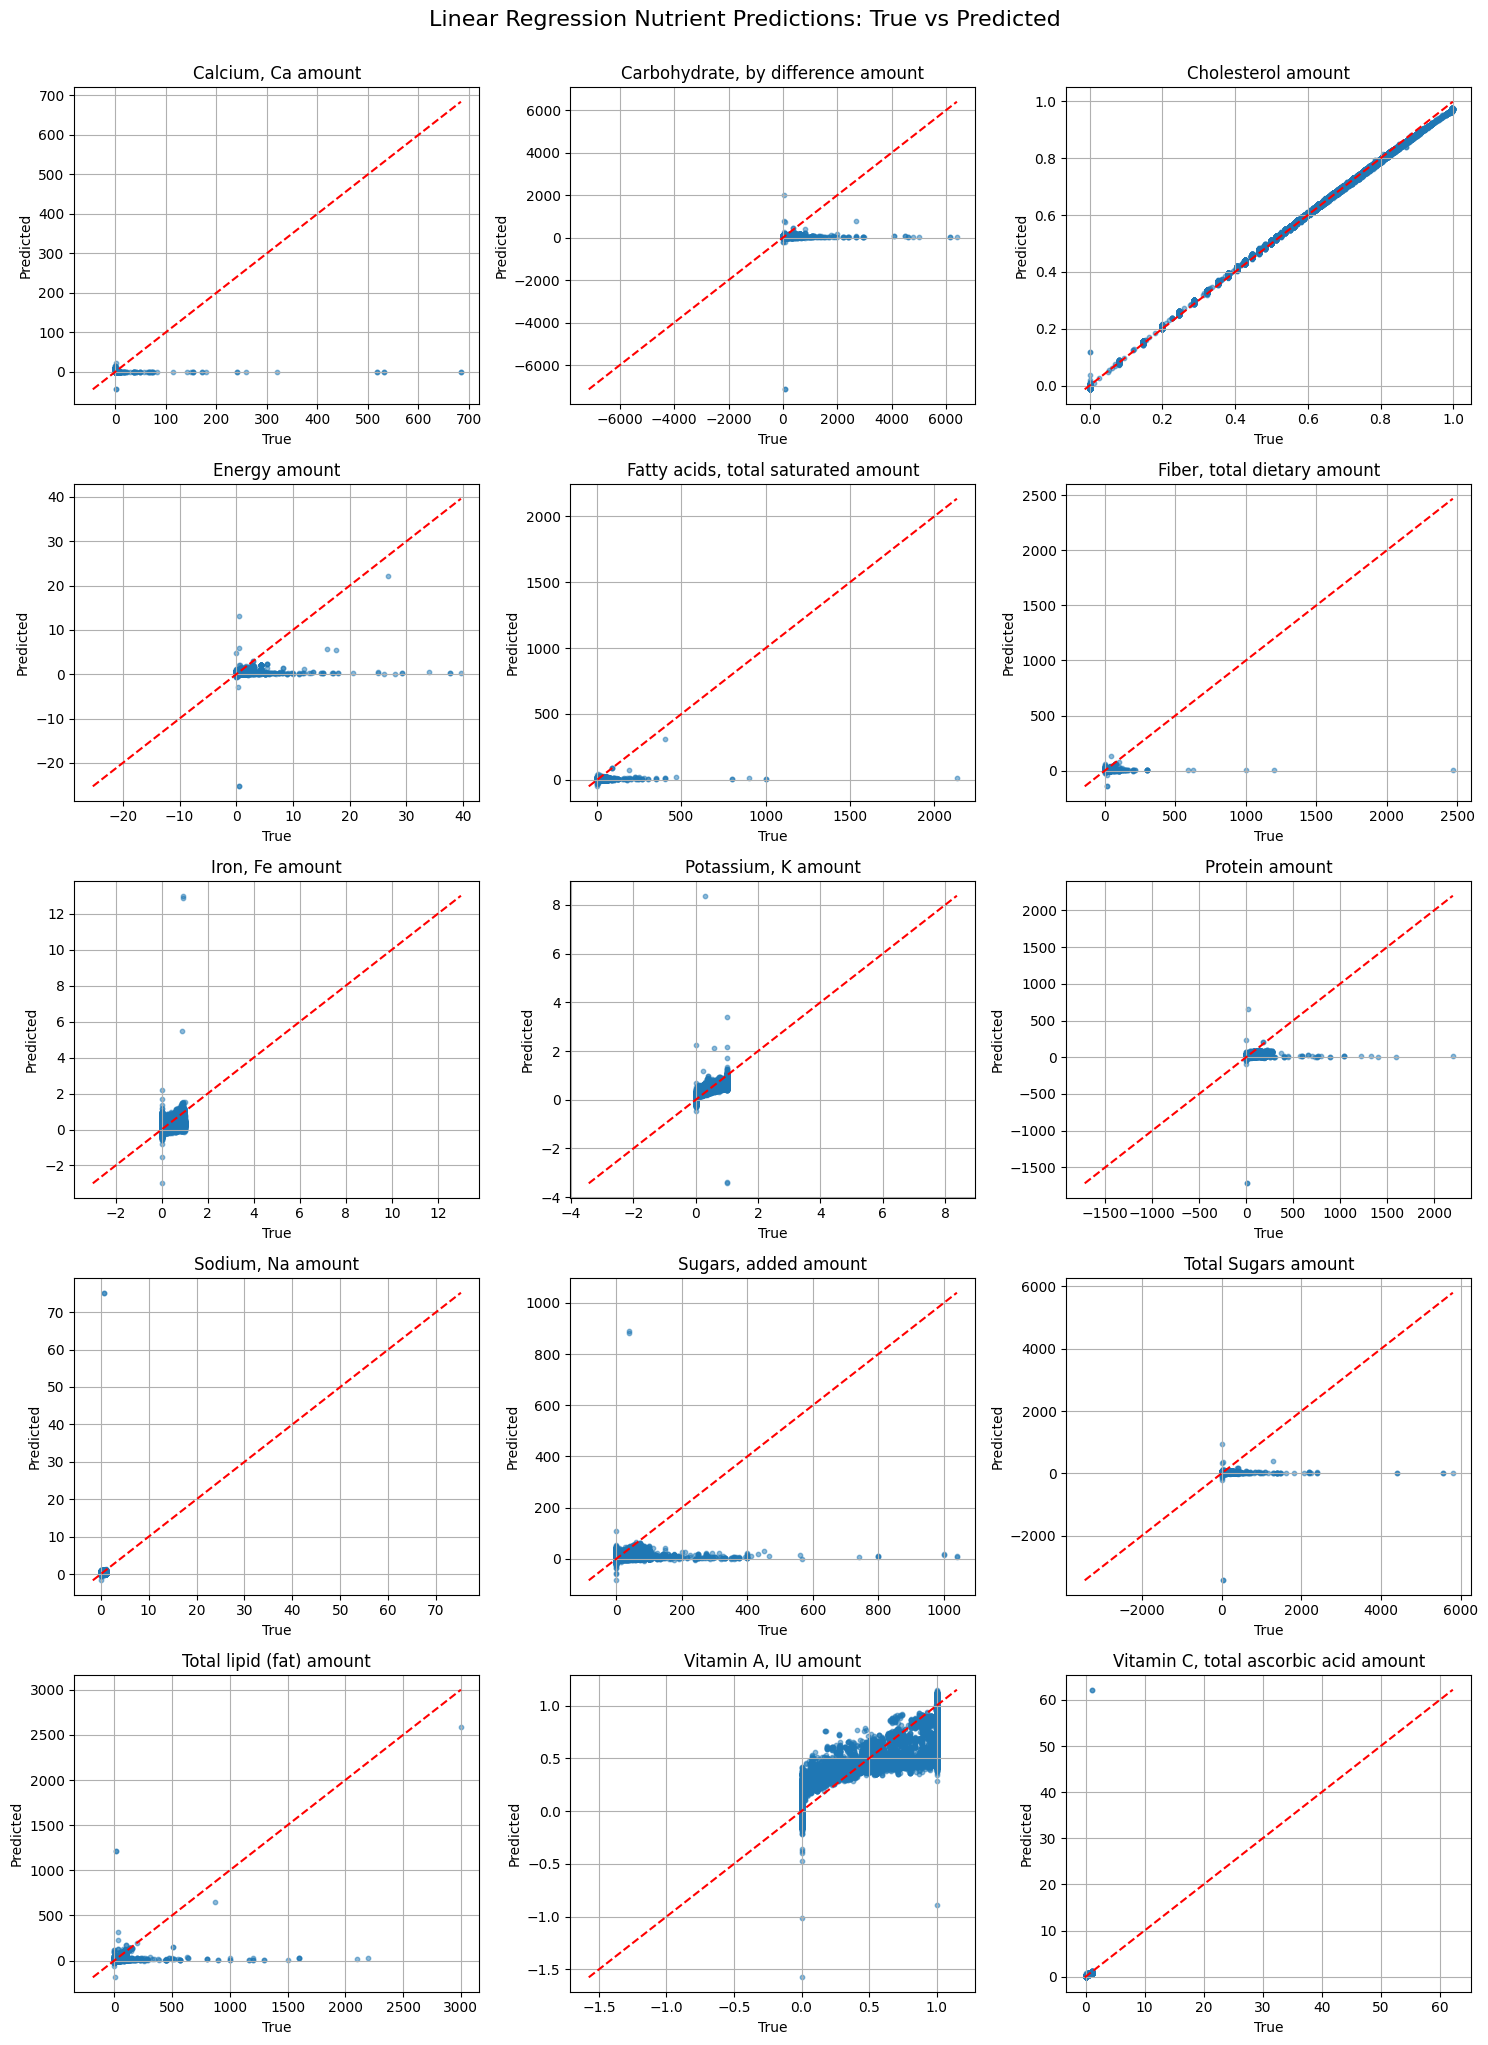

In [21]:
# Visualize linear regression predictions: scatter plots for each nutrient
num_nutrients = len(nutrient_cols)
cols = 3
rows = int(np.ceil(num_nutrients / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(nutrient_cols):
    ax = axes[i]
    ax.scatter(y_test[:, i], y_pred_lr[:, i], alpha=0.5, s=10)
    min_val = min(np.min(y_test[:, i]), np.min(y_pred_lr[:, i]))
    max_val = max(np.max(y_test[:, i]), np.max(y_pred_lr[:, i]))
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_title(col)
    ax.grid(True)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Linear Regression Nutrient Predictions: True vs Predicted', y=1.02, fontsize=16)
plt.show()